Croston - Croston's method separates the intermittent demand data into two separate sequences, one for the non-zero demand and another for the intervals between non-zero demands. The method then applies separate exponential smoothing on both.

The Croston method is a forecasting technique used for products with intermittent demand, meaning there are many periods with zero demand and only occasional non-zero sales. It works by separately applying simple exponential smoothing to the size of the demand and the time interval between demands, which is a more accurate approach than standard forecasting methods for this type of data

Ex:
An online retailer selling rare collectible items, unique craft supplies, or specialty electronics can use Croston's method to manage their inventory. The demand for a specific product might be zero for long periods, followed by a sudden order. Croston's helps prevent overstocking and reduces inventory holding costs for these slow-moving SKUs.

Spare parts: Manufacturers often need to stock replacement parts for products that are no longer in production. Demand for a specific spare part might be intermittent, occurring only when a breakdown happens. By applying Croston's method, the manufacturer can forecast the irregular demand patterns more accurately to ensure parts are available without tying up excessive capital in inventory.

Specialty pharmaceuticals: A pharmaceutical company may produce specific drugs with a very long shelf life that are rarely prescribed. Using Croston's method, they can forecast the occasional need for these products and manage production schedules to prevent shortages and minimize waste.

In [ ]:
# Install
!pip install pyInterDemand

In [ ]:
# Required Libraries
import pandas as pd
from pyInterDemand.algorithm.intermittent import plot_int_demand, classification, mase, rmse
from pyInterDemand.algorithm.intermittent import croston_method

In [ ]:
# Load Dataset
data = {
        'DATE': pd.Series(['21/08/2020','22/08/2020', '23/08/2020', '24/08/2020', '25/08/2020', '26/08/2020', '27/08/2020', '28/08/2020', '29/08/2020', '30/08/2020', '31/08/2020', '01/09/2020']),
       'Price Value': pd.Series([5, 10, 0, 0, 0, 0, 7, 0, 0, 0, 6, 0]),
       }
dataset = pd.DataFrame(data)
dataset['DATE'] = pd.to_datetime(dataset['DATE'], dayfirst = True).map(lambda x: x.strftime('%d-%m-%Y'))
dataset

,DATE,Price Value
0,21-08-2020,5
1,22-08-2020,10
2,23-08-2020,0
3,24-08-2020,0
4,25-08-2020,0
5,26-08-2020,0
6,27-08-2020,7
7,28-08-2020,0
8,29-08-2020,0
9,30-08-2020,0


In [ ]:
# Prepare Time Series TS
ts       = dataset['Value'].copy(deep = True)
ts.index = pd.DatetimeIndex(dataset['DATE'], dayfirst = True)
ts       = ts.sort_index()
ts       = ts.reindex(pd.date_range(ts.index.min(), ts.index.max()), fill_value = 0)
ts       = ts.loc[ts[(ts != 0)].first_valid_index():]

print('')
print('Total Number of Observations: ', ts.shape[0])
print('Total Number of Zeros: ', len(ts[ts == 0]))
print('Start Date: ', ts.index[0])
print('End Date: '  , ts.index[-1])
print('')

KeyError: 'Value'

In [ ]:
# Time Series Classification
adi, cv_sq = classification(ts)

ADI:  3.0 , CV:  3.611 , Type:  Lumpy


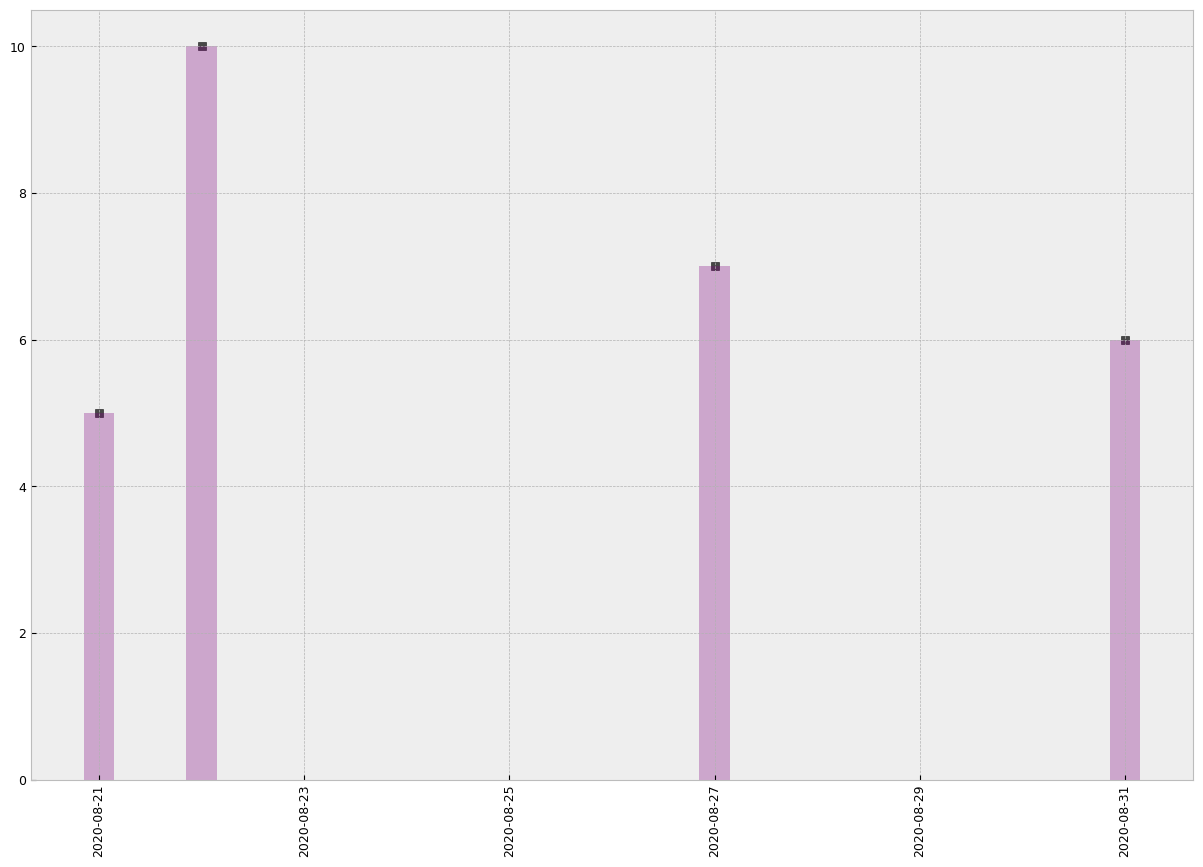

In [ ]:
# Time Series Plot
plot_int_demand(ts, size_x = 15, size_y = 10, bar_width = 0.3)

Pattern of Intermittent Demand

The graph illustrates sporadic (irregular) demand occurrences.

There are multiple periods with zero demand (visible as gaps on the timeline), indicating no sales or usage.
Demand spikes are observed only on a few specific dates — for example, around August 21, 22, 27, and 31 in 2020.

Demand Magnitude
The highest demand is recorded on August 22, 2020, reaching approximately 10 units.
Other demand instances are moderate, typically ranging between 5 and 7 units.

Implications for Forecasting
This dataset represents a typical intermittent demand pattern, where traditional time series models (such as ARIMA or exponential smoothing) may not perform effectively.

Croston’s method is more suitable in this context, as it separately models:
•	The size of non-zero demand
•	The interval between non-zero demands
This approach provides a stable average forecast that reflects expected demand per period based on both components.

Business Interpretation
Products with such demand patterns are often slow-moving items or spare parts.
Instead of continuous replenishment, businesses should maintain a moderate level of safety stock.
Forecast-based inventory planning helps prevent both overstocking (due to infrequent demand) and stockouts (when demand arises unexpectedly).



/usr/local/lib/python3.12/dist-packages/pyInterDemand/algorithm/intermittent.py:105: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  v_i[0]        = ts[0]
/usr/local/lib/python3.12/dist-packages/pyInterDemand/algorithm/intermittent.py:105: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  v_i[0]        = ts[0]
/usr/local/lib/python3.12/dist-packages/pyInterDemand/algorithm/intermittent.py:106: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] 

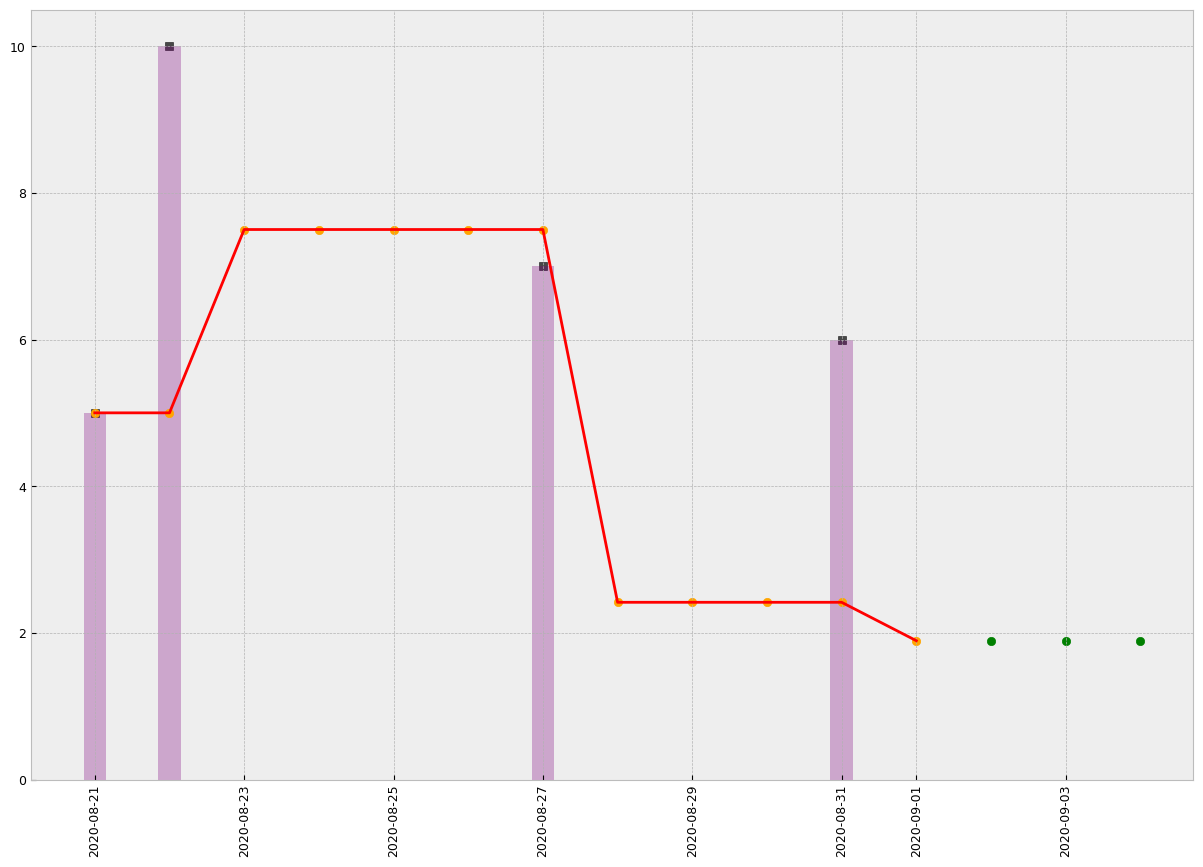

In [ ]:
# Croston
v, q, forecast = croston_method(ts, alpha = 0.5, n_steps = 4, freq = '1d')
plot_int_demand(ts, size_x = 15, size_y = 10, bar_width = 0.3, prediction = forecast)



Actual Demand (Purple Bars)

The purple bars represent the actual observed demand over time.

The demand is intermittent — with several days showing zero demand, followed by sudden spikes on specific dates (e.g., around August 21, 22, 27, and 31).

This pattern indicates sporadic demand, which is typical for slow-moving inventory or spare parts.

Fitted Values (Red Line with Orange Dots)
The red line illustrates the fitted demand forecast generated using Croston’s method.

After each non-zero demand, the red line adjusts upward or downward, reflecting exponential smoothing updates for both demand size and the interval between demands.
During periods of zero demand, the forecast line remains flat, indicating no change in expected demand.

Forecasted Periods (Green Dots)
The green dots beyond the historical data represent forecasted demand for future periods.

These values remain constant, as Croston’s method assumes a steady future demand rate based on the most recent smoothed estimates.

This approach is particularly useful for planning when the exact timing of demand is uncertain, but the average rate can still be predicted.

Pattern Observations
Following the initial high demand, the forecast stabilizes at a moderate level and then slightly declines.

This suggests a decrease in either the frequency or size of demand toward the end of the observed period.
Overall, the model effectively smooths out irregular spikes, avoiding overreaction to isolated high-demand events.

Business Insight
The product exhibits intermittent purchasing behavior — it is not needed frequently but is demanded in bursts.
The Croston forecast (green dots) offers a stable estimate of expected demand per period, aiding in more efficient inventory and replenishment planning.
This allows businesses to maintain minimal stock levels, reduce carrying costs, and still be prepared for occasional demand surges.



In [ ]:
# Error
print('MASE = ', round(mase(ts, forecast), 3), ', RMSE = ', round(rmse(ts, forecast), 3))

MASE =  1.078 , RMSE =  4.867


/usr/local/lib/python3.12/dist-packages/pyInterDemand/algorithm/intermittent.py:81: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  divisor = divisor + abs(ts[i] - ts[i-1])


Forecast Accuracy Metrics


Mean Absolute Scaled Error (MASE) = 1.078
MASE compares the accuracy of your forecasting model to that of a naïve forecast (which simply predicts the previous period’s demand).

A MASE value close to 1 indicates that Croston’s method performs similarly to the naïve model.

In this case, the MASE is slightly above 1, suggesting that Croston’s method is marginally less accurate than the naïve forecast.

However, for intermittent demand data, a MASE around 1 is generally considered acceptable, as such demand is inherently difficult to predict.


Root Mean Squared Error (RMSE) = 4.867
RMSE measures the average magnitude of forecast errors, giving more weight to larger errors.

Here, the forecasted demand deviates from the actual demand by approximately 4.87 units on average.

Given that the actual demand values typically range between 0 and 10, this RMSE indicates a moderate level of forecasting error.

The presence of zero-demand periods and occasional demand spikes contributes to this variability, which is expected in intermittent demand series.